# Laboratorio 6

## Integrantes

| Nombre                            | Carnet | Usuario Git |
| --------------------------------- | ------ | ----------- |
| Edwin Jose Gabriel De Leon Garcia | 22809  | EJGDLG      |
| Gustavo Adolfo Cruz Bardales      | 22779  | G2309       |
| Josué Emanuel Say Garcia          | 22801  | JosueSay    |
| Mathew Alexander Cordero Aquino   | 22982  | donmatthiuz |


## Repositorio

[Link al Repositorio](https://github.com/donmatthiuz/RL/tree/lab6)

## Contexto

Una empresa de robótica de asistencia médica está desarrollando un exoesqueleto para rehabilitación de movilidad en pacientes con lesiones de rodilla. El sistema de control debe aprender a asistir el movimiento de la pierna del paciente de forma suave y eficiente, minimizando el esfuerzo del motor y maximizando la fluidez del movimiento. Antes de trabajar con el hardware real, el equipo de ingeniería necesita validar si los métodos de gradiente de política son apropiados para este dominio de control continuo, usando entornos de simulación estándar como proxy del problema real.

Su grupo ha sido contratado para implementar y comparar REINFORCE con línea base y un Actor-Critic simple, analizar sus propiedades de convergencia, e investigar el estado del arte en control de exoesqueletos con RL para producir un dictamen técnico fundamentado.

## Notas a Considerar

1. Dependencias permitidas: `gymnasium`, `numpy`, `matplotlib`, `torch`. No se permiten implementaciones preconstruidas de REINFORCE, Actor-Critic o PPO de librerías de RL.
2. Instalar el entorno con: `pip install gymnasium[box2d]`.
3. El paper debe citarse correctamente con autores, título, venue y año. Incluyan DOI o enlace arXiv.

## Task 1

Respondan las siguientes preguntas con argumentación técnica rigurosa antes de implementar nada:

### Inciso 1

El entorno de simulación que usarán es LunarLanderContinuous-v2 de Gymnasium, que tiene un espacio de acción continuo de dos dimensiones representando la fuerza de los dos propulsores. Argumenten formalmente por qué Q-Learning tabular y DQN son inapropiados para este entorno. Su argumento debe mencionar explícitamente el espacio de acción, el operador $\arg\max_a$, y la representación de la política.

**Respuesta:**

El entorno recibe dos números reales: cuánto empuja el motor principal y cuánto empujan los laterales. Ambos viven en $[-1,1]$, así que el conjunto de acciones es $\mathcal{A}=[-1,1]^2\subset\mathbb{R}^2$. Está acotado, pero contiene infinitos puntos del continuo, como los reales.

Q-Learning tabular guarda un número por cada par $(s,a)$, lo que solo funciona si las acciones se pueden listar. Aquí no se puede: entre $0.1$ y $0.2$ hay infinitas acciones válidas, así que la tabla no se construye. La salida obvia es discretizar, digamos 10 valores por eje, y trae dos costos. Dos empujes distintos que caen en la misma casilla reciben el mismo valor por diseño, y ese error no se corrige entrenando más; además la tabla explota, porque con 10 niveles en las 8 dimensiones del estado y en las 2 de acción son $10^{10}$ casillas. El problema mayor no es la memoria sino que cada casilla se aprende sola: visitar una no enseña nada sobre la vecina, así que con cualquier presupuesto realista de episodios casi todas se quedan con el valor de inicialización. En un espacio continuo eso es fatal, porque el agente nunca ve dos veces exactamente el mismo estado.

DQN arregla la mitad del problema, ya que la red generaliza entre estados parecidos, que es justo lo que la tabla no hacía. Pero su capa de salida tiene una neurona por acción, lo que obliga a que las acciones sean finitas y conocidas de antemano. No hay forma de poner una neurona por cada punto de $[-1,1]^2$.

El segundo obstáculo es el operador del que ambos métodos sacan su política, $\pi(s)=\arg\max_{a\in\mathcal{A}}Q(s,a)$. Es decir, no deciden: comparan. Con acciones discretas eso es barato, se miran las salidas y se elige la mayor. Con acciones continuas ya no hay nada que comparar y hay que buscar el máximo de una función sobre un conjunto infinito, que es un problema de optimización completo. Como $\hat{Q}_w(s,\cdot)$ es una red neuronal, esa función tiene varios máximos locales y ningún método de búsqueda garantiza encontrar el mejor.

El $\arg\max$ aparece dos veces y no una: al elegir la acción, una vez por paso, y dentro del objetivo de la actualización en el término $\max_a Q(S_{t+1},a)$, una vez por transición. La segunda aparición es la peor, porque si ese máximo se calcula mal el error entra en la señal con la que el agente aprende y se propaga. Y un exoesqueleto decide entre 100 y 1000 veces por segundo, y resolver una optimización con decenas de evaluaciones de la red en cada decisión no es realista. Una variante que aparece de inmediato es que la red reciba $(s,a)$ junta y devuelva un escalar, lo que permite evaluar acciones continuas, pero no resuelve nada porque para elegir hay que seguir buscando el máximo sobre $a$; y además deja de ser el DQN estándar.

En estos métodos la política no existe como objeto, no hay una función que se pueda mirar, guardar o ajustar, sino una tabla de valores y una regla aplicada encima.

- Siempre es determinista. El máximo devuelve un punto, nunca una mezcla de acciones, así que si la política óptima necesita ser aleatoria este enfoque no puede representarla. Añadir $\varepsilon$-greedy no cuenta, porque es ruido pegado por fuera durante el entrenamiento y no una política que aprendió a ser aleatoria.
- No se puede derivar. Como la política no tiene parámetros propios, no hay nada respecto a lo cual calcular un gradiente, y queda fuera del alcance del ascenso por gradiente sobre el retorno.
- Cambia a saltos. Mover un poco los pesos $\mathbf{w}$ puede cambiar por completo cuál es la acción ganadora en un estado, así que la política salta aunque la estimación de valor esté mejorando suavemente.

Una política que salta produce cambios bruscos de torque sobre la rodilla del paciente mientras entrena. El gradiente de política define $\pi_\theta(a\mid s)$ como una distribución explícita con sus propios parámetros, y con eso obtiene lo que faltaba: acciones continuas sin discretizar, aleatoriedad si conviene, y cambio suave cuando cambian los parámetros.

### Inciso 2

Para LunarLanderContinuous-v2, la política se parametrizará como una distribución Gaussiana

$\pi_\theta(a\mid s)=\mathcal{N}(\mu_\theta(s),\sigma^2 I)$ donde $\mu_\theta(s)$ es la salida de una red neuronal. Expliquen cómo se calcula $\nabla_\theta \ln \pi_\theta(A_t\mid S_t)$ para esta parametrización específica. Desarrollen la expresión analítica del gradiente del logaritmo de la densidad Gaussiana respecto a $\theta$, identificando qué parte depende de $\theta$ y qué parte no.

**Respuesta:**

La política no devuelve una acción sino una campana de Gauss centrada en $\mu_\theta(s)$, y la acción se saca sorteando de esa campana. La red decide dónde está el centro y $\sigma$ dice qué tan ancha es, así que aprender es mover el centro. Lo que hay que calcular es cuánto se mueve el centro al tocar los pesos, y eso es exactamente $\nabla_\theta\ln\pi_\theta(A_t\mid S_t)$.

Con $d=2$ dimensiones de acción y $\sigma$ fija, la densidad es

$$
\pi_\theta(a\mid s)=\frac{1}{(2\pi\sigma^2)^{d/2}}\exp\left(-\frac{\lVert a-\mu_\theta(s)\rVert^2}{2\sigma^2}\right)
$$

Como la covarianza es $\sigma^2I$, las dos coordenadas son independientes y el motor principal y los laterales se sortean por separado. Tomando logaritmo, el exponente baja y el producto se vuelve suma:

$$
\ln\pi_\theta(a\mid s)=\underbrace{-\frac{d}{2}\ln(2\pi\sigma^2)}_{\text{normalización}}\;\underbrace{-\;\frac{1}{2\sigma^2}\sum_{i=1}^{d}\left(a_i-\mu_{\theta,i}(s)\right)^2}_{\text{exponente}}
$$

Separar qué depende de $\theta$ es el punto del inciso, y hace que el cálculo salga casi solo.

| Elemento | ¿Depende de $\theta$? | Qué pasa con él |
| :--- | :--- | :--- |
| $-\frac{d}{2}\ln(2\pi\sigma^2)$ | No | Es una constante. Su derivada es cero y desaparece del gradiente. |
| $a$, la acción sorteada | No | Ya se sorteó y se ejecutó. Es un dato fijo. |
| $\sigma$ | No, por hipótesis | Solo escala el resultado. |
| $\mu_\theta(s)$ | Sí | La red. Es lo único que el gradiente puede mover. |

Que el término de normalización no dependa de $\theta$ es lo que hace tratable a toda la familia de métodos, porque deja solo el exponente por derivar. Conviene evitar un error común: el residuo $a-\mu_\theta(s)$ sí depende de $\theta$ a través de la media.

Derivando el exponente respecto a la media, coordenada por coordenada, se obtiene $\partial/\partial\mu_i\left[-(a_i-\mu_i)^2/2\sigma^2\right]=(a_i-\mu_i)/\sigma^2$, y como la red conecta $\mu$ con $\theta$, la regla de la cadena da

$$
\frac{\partial}{\partial\theta_j}\ln\pi_\theta(a\mid s)=\sum_{i=1}^{d}\frac{a_i-\mu_{\theta,i}(s)}{\sigma^2}\,\frac{\partial\mu_{\theta,i}(s)}{\partial\theta_j}
$$

Llamando $J_\mu(s)=\partial\mu_\theta(s)/\partial\theta\in\mathbb{R}^{d\times|\theta|}$ al Jacobiano de la red, la forma vectorial es

$$
\nabla_\theta\ln\pi_\theta(a\mid s)=J_\mu(s)^\top\,\frac{a-\mu_\theta(s)}{\sigma^2}
$$

y el resultado tiene la misma dimensión que $\theta$, como debe ser. Cada pieza cumple un papel distinto: $a-\mu_\theta(s)$ es la flecha que va del centro de la campana a la acción sorteada e indica hacia dónde; $J_\mu^\top$ traduce esa flecha, que vive en el espacio de acciones, a un cambio de pesos, y es lo que hace *backpropagation*; $1/\sigma^2$ escala el tamaño del paso.

Multiplicando por la ventaja se ve el mecanismo completo:

$$
\theta\leftarrow\theta+\alpha\,\hat{A}_t\,J_\mu(S_t)^\top\frac{A_t-\mu_\theta(S_t)}{\sigma^2}
$$

Si la acción salió bien, con $\hat{A}_t>0$, el centro se mueve hacia ella y la próxima vez es más probable; si salió mal, se aleja. El azar de la campana propone y el signo de la ventaja decide si esa propuesta se queda, que es la separación de la nota entre dirección, dada por la *score function*, y magnitud, dada por la ventaja. En la práctica conviene notar que el factor $1/\sigma^2$ se dispara si $\sigma$ se acerca a cero: para acciones en $[-1,1]$, un $\sigma$ inicial de $0.4$ a $0.6$ explora sin pegarse a los bordes, y conviene *gradient clipping* justamente por ese término.

Si $\sigma$ también se aprende, la normalización deja de ser constante y aparece un segundo sumando. Con $r=a-\mu_\theta(s)$:

$$
\nabla_\theta\ln\pi_\theta(a\mid s)=J_\mu(s)^\top\frac{r}{\sigma_\theta(s)^2}+\left(\frac{\lVert r\rVert^2}{\sigma_\theta(s)^2}-d\right)\nabla_\theta\ln\sigma_\theta(s)
$$

Ese sumando se anula si $\sigma$ es fija, y su signo tiene lectura directa: si las acciones caen más lejos del centro de lo que $\sigma$ predecía, empuja a ensanchar la campana, y si caen más cerca, a angostarla. Es decir, la política aprende cuánto explorar. Si media y desviación comparten capas, ambos términos actualizan esos pesos; con cabezas separadas, cada bloque recibe solo el suyo. Se parametriza $\ln\sigma$ en vez de $\sigma$ para garantizar que sea positiva sin restricciones y para evitar que el optimizador la lleve a la zona donde $1/\sigma^2$ explota.


### Inciso 3

Comparen formalmente REINFORCE con línea base y Actor-Critic en términos de sesgo y varianza del estimador del gradiente. Para cada algoritmo identifiquen: qué usa como retorno $\hat{A}_t$, qué componente introduce sesgo, y qué componente introduce varianza. Predigan cuál algoritmo esperan que converja más rápido en LunarLanderContinuous-v2 y justifiquen esa predicción.

**Respuesta:**

Los dos algoritmos son la misma actualización, $\theta\leftarrow\theta+\alpha\hat{A}_t\nabla_\theta\ln\pi_\theta$, y solo cambian en cómo estiman $\hat{A}_t$:

REINFORCE espera a que termine el episodio y usa lo que realmente pasó, mientras Actor-Critic no espera y usa lo que el crítico predice.

| | REINFORCE con línea base | Actor-Critic |
| :--- | :--- | :--- |
| $\hat{A}_t$ | $G_t-b_w(S_t)$ | $\delta_t=R_{t+1}+\gamma\hat{V}_w(S_{t+1})-\hat{V}_w(S_t)$ |
| ¿Estima bien $A^\pi$? | No, si $b_w\neq V^\pi$: da $Q^\pi-b_w$ en vez de $Q^\pi-V^\pi$ | No: el bootstrapping con $\hat{V}_w$ imperfecta lo sesga |
| ¿Estima bien el gradiente? | Sí: lo que se resta no depende de la acción y se cancela | No: el sesgo depende de la acción y no se cancela |
| De dónde sale la varianza | $G_t$ arrastra todo lo que pasó hasta el final | Una sola transición más el error del crítico |
| Cuándo actualiza | Al terminar el episodio | En cada paso |
| ¿Sirve para tareas continuas? | No | Sí |
| Papel de $\hat{V}_w$ | Accesorio: solo baja varianza | Esencial: es la señal de aprendizaje |

Que la línea base no sesgue el gradiente es lo que hace que restar $b(S_t)$ salga gratis. Para cualquier $b$ que no dependa de la acción,

$$
\mathbb{E}_{A\sim\pi_\theta}\!\left[b(s)\nabla_\theta\ln\pi_\theta(A\mid s)\right]=b(s)\nabla_\theta\!\!\int_{\mathcal{A}}\!\pi_\theta(a\mid s)\,da=b(s)\nabla_\theta 1=0
$$

así que lo restado tiene esperanza exactamente cero y el gradiente promedio no se mueve. La condición imprescindible es que $b$ no dependa de $A_t$, porque si dependiera no podría salir de la integral. Aunque $b_w$ sea una mala aproximación de $V^\pi$, el gradiente sigue apuntando bien en promedio, y una línea base mala no sesga sino que elimina menos varianza.

Si $w$ está fijo al momento de sortear la acción; si el crítico se ajusta con el mismo lote y esa predicción se reutiliza enseguida, $w$ pasa a depender de las acciones del lote y la cancelación deja de ser automática. Se evita ajustando el crítico antes del actor, o con datos separados. En Actor-Critic no hay rescate equivalente. Llamando $e_w(s)=\hat{V}_w(s)-V^\pi(s)$ al error del crítico,

$$
\mathbb{E}[\delta_t\mid s,a]-A^\pi(s,a)=\gamma\,\mathbb{E}[e_w(S_{t+1})\mid s,a]-e_w(s)
$$

El primer término depende de la acción porque la acción determina a qué estado se llega. No es una constante del estado que se cancele al promediar, así que el sesgo pasa entero al gradiente y solo desaparece si el crítico es exacto, cosa que no ocurre en un entrenamiento finito. Se suma un segundo sesgo distinto: en la práctica se ignora el factor $\gamma^t$ de la actualización, así que los estados no se visitan con la distribución que el teorema supone, y este no se arregla entrenando más al crítico.

En REINFORCE la varianza $G_t$ es la suma de todo lo que pasó desde $t$ hasta el final es decir que cada acción sorteada, cada transición del entorno, y hasta cuánto duró el episodio, todo aleatorio y acumulado; la línea base quita la parte predecible dado el estado, pero no toca la aleatoriedad del futuro, que es la dominante. Hay un problema extra específico de este entorno, el $\pm100$ del final, aterrizaje o choque, pesa más que todo lo demás junto y entra en $G_t$ de todos los pasos del episodio, así que si terminó en choque hasta las maniobras correctas reciben señal negativa. Es la asignación de crédito difusa, y es exactamente lo que Actor-Critic resuelve, porque $\delta_t$ mira una sola transición y todo el futuro queda comprimido dentro de $\hat{V}_w(S_{t+1})$, que es un número fijo dado el estado y no una variable aleatoria. Cambiar una suma de cientos de términos aleatorios por una evaluación de red es el mismo intercambio que TD hacía sobre Monte Carlo en la semana 6.

La predicción es que Actor-Critic converja más rápido en este entorno:

- Los episodios duran entre 200 y 1000 pasos, y la varianza de $G_t$ crece con esa longitud, así que es el peor escenario para REINFORCE.
- Actualiza cientos de veces por episodio contra una sola de REINFORCE, de modo que con el mismo gasto de interacción da dos o tres órdenes de magnitud más pasos de optimización.
- El crítico aprende a anticipar el $\pm100$ terminal y lo descuenta, dejando que $\delta_t$ mida la contribución real de cada acción.
- La recompensa es densa —distancia al objetivo, velocidad, ángulo, $-0.3$ por frame del motor principal—, así que hay señal útil en cada paso y el crítico es aprendible sin depender de eventos raros.

Al principio el crítico es ruido y es esperable que REINFORCE se vea mejor en los primeros episodios, con el cruce llegando cuando $\hat{V}_w$ empieza a informar. Actor-Critic tiene además dos tasas acopladas, y la convención es $\alpha_w>\alpha_\theta$ porque el crítico debe ir adelante; mal calibradas divergen, donde REINFORCE solo sería lento. Lo probable es una curva más rápida pero con más riesgo de colapso, así que hay que reportar la varianza entre semillas y no solo la media. Para comprobarlo conviene graficar contra pasos de entorno y no contra episodios, porque en episodios la comparación favorece de forma artificial a REINFORCE, que gasta muchos más pasos por cada actualización; y si aun así Actor-Critic no llega antes a los 200 puntos, lo primero a revisar es el balance entre $\alpha_\theta$ y $\alpha_w$, no el argumento teórico.

### Inciso 4

El entorno de exoesqueleto real tiene una restricción que LunarLanderContinuous-v2 no tiene: las acciones deben ser suaves en el tiempo para no causar movimientos bruscos que dañen al paciente. Argumenten cómo modificarían la función de recompensa y la parametrización de la política para incorporar esa restricción. ¿Cambiaría eso la elección entre REINFORCE y Actor-Critic?

**Respuesta:**


La restricción es que el torque no dé saltos de un paso al siguiente, y se ataca por dos lados: la recompensa castiga los saltos, y la parametrización hace que ni siquiera se puedan producir. El segundo lado es el importante, porque una penalización solo enseña después de que el salto ocurrió, y aquí eso significa aprender lastimando al paciente.

Lo primero que sale es penalizar el cambio entre acciones consecutivas, $r'_t=r_t-\lambda\lVert a_t-a_{t-1}\rVert^2$. Es correcto en intención, pero así escrito rompe la propiedad de Markov, porque la recompensa depende de $a_{t-1}$, que no está dentro del estado: dos situaciones idénticas según $s_t$ pero con distinto torque previo darían recompensas distintas, y un MDP no admite eso. Todo lo derivado antes, el teorema de gradiente de política incluido, se apoya en esa propiedad. Se arregla metiendo la acción anterior en el estado, $\tilde{s}_t=(s_t,a_{t-1})$, con el actor y el crítico recibiendo $\tilde{s}_t$.

Con el estado ya corregido, la recompensa completa para el exoesqueleto, con $q$ el ángulo de rodilla, $\tau_t$ el torque y $q^{\text{ref}}$ la trayectoria del protocolo de terapia, queda

$$
R_{t+1}=-w_1\lVert q_t-q^{\text{ref}}_t\rVert^2-w_2\lVert\tau_t\rVert^2-w_3\lVert\tau_t-\tau_{t-1}\rVert^2-w_4\lVert\ddot{q}_t\rVert^2-C\cdot\mathbb{1}[\text{límite violado}]
$$

| Término | Qué castiga | Por qué está |
| :--- | :--- | :--- |
| Seguimiento | Alejarse de la trayectoria terapéutica | Es la tarea. Sin esto no hay objetivo. |
| Esfuerzo | Torque grande | Minimizar el esfuerzo del motor, del enunciado. |
| Suavidad | Que el motor cambie de golpe | Es la restricción nueva. |
| Jerk | Que la pierna se acelere de golpe | Es lo que el paciente siente como tirón. |
| Seguridad | Pasarse del rango articular | Límite que no se negocia. |

Suavidad y jerk no son lo mismo aunque lo parezcan: uno mira el motor y el otro mira la pierna, y entre ambos está la física del paciente es decir el peso del segmento, la rigidez de la articulación, la fuerza que el propio paciente esté haciendo, así que un mando suave puede terminar en un movimiento brusco. Al paciente lo lastima el segundo, no el primero. La seguridad, por su parte, no debería vivir solo en la recompensa: una penalización es negociable, porque si la tarea da suficiente recompensa al agente le puede convenir pagar el castigo, y ningún $\lambda$ finito garantiza nada fuera de los datos que vio entrenando. Los límites articulares van en un tope físico externo que el agente no pueda saltarse, y la penalización solo sirve para que aprenda a no acercarse.

Sobre la forma de la penalización: se elige al cuadrado porque es derivable en cero, es simétrica, y castiga mucho más los saltos grandes, que son los peligrosos. Si el periodo de control $\Delta t$ es fijo, penalizar la velocidad de cambio $\lVert(a_t-a_{t-1})/\Delta t\rVert^2$ es lo mismo que absorber $1/\Delta t^2$ dentro de $\lambda$. Y las acciones hay que normalizarlas por el límite de cada motor, o el de mayor rango domina la norma solo por sus unidades. Los pesos $w_1$ a $w_4$ no se pueden fijar desde el escritorio: se escalan los términos a magnitud comparable en el rango de operación y luego se suben $w_3$ y $w_4$ hasta que un fisioterapeuta apruebe el movimiento, porque el criterio final es clínico y no numérico.

En cuanto a la parametrización, la idea es que el salto brusco sea imposible de generar y no solo caro. En vez de que la red proponga un torque libre, se le acota de antemano cuánto puede moverse respecto al anterior. Con $a_{\min}$ y $a_{\max}$ los límites del motor y $\rho$ el cambio máximo permitido por paso, se define en cada instante una ventana $\ell_t=\max(a_{\min},a_{t-1}-\rho)$ y $h_t=\min(a_{\max},a_{t-1}+\rho)$. La red sortea una variable auxiliar $U_t\sim\mathcal{N}(\mu_\theta(\tilde{s}_t),\operatorname{diag}(\sigma_\theta(\tilde{s}_t)^2))$ y la acción sale de aplastarla dentro de esa ventana:

$$
A_t=\ell_t+(h_t-\ell_t)\odot\frac{\tanh(U_t)+1}{2}
$$

Como $\tanh$ vive entre $-1$ y $1$, el resultado siempre cae dentro de $[\ell_t,h_t]$, lo que garantiza dos cosas a la vez para cualquier valor de los pesos: el torque respeta los límites del motor y no se aleja más de $\rho$ del torque anterior. No es algo que el agente tenga que aprender ni que dependa de que el entrenamiento haya salido bien, sino la forma misma de la política. Un detalle de implementación que se pasa por alto seguido es que al entrenar hay que usar la densidad transformada, incluyendo el término de corrección del cambio de variable de $\tanh$; sortear una gaussiana y recortarla después no es lo mismo, y amontona probabilidad falsa en los bordes.

Conviene acotar $\ln\sigma_\theta$ por arriba y por abajo, donde el techo evita que la política tiemble sorteando acciones muy dispersas y el piso evita que la exploración se apague antes de haber aprendido. Una distribución Beta por coordenada también funcionaría, ya que queda acotada sin necesidad de recortar, pero se prefiere la gaussiana transformada para no cambiar la parametrización del inciso 2.

Todo esto sí cambia la elección entre los dos algoritmos, y la inclina más hacia Actor-Critic:

- El castigo por brusquedad es local y REINFORCE lo diluye: el término $-w_3\lVert\tau_t-\tau_{t-1}\rVert^2$ señala un instante concreto y el error TD le asigna la culpa a esa transición, mientras que en REINFORCE se mezcla dentro de $G_t$ con todo el episodio, de modo que una sesión con buen seguimiento y un solo tirón da retorno alto y el tirón se pierde en el promedio. Actor-Critic castiga el tirón donde ocurrió; REINFORCE no.
- La rehabilitación no tiene episodios, porque un ciclo de terapia no termina en ningún punto natural, y REINFORCE necesita episodios completos para calcular $G_t$; sin ellos no es aplicable, lo que por sí solo cierra la pregunta.
- En simulación la varianza de REINFORCE cuesta episodios, pero con un paciente cada actualización ruidosa es una sesión de terapia con movimiento peor de lo necesario. Y el crítico sirve para algo más que entrenar, porque $\hat{V}_w(s)$ estima qué tan bien va la situación y puede usarse como alarma: si el valor cae de golpe, se le devuelve el control a un controlador clásico. Conviene cerrar con un matiz sobre el hardware, y es que la elección real no está entre estos dos sino en PPO con GAE, algo que la restricción de suavidad refuerza.
- El *clipping* limita cuánto puede cambiar la política de una actualización a la siguiente, lo que aquí significa que el comportamiento aplicado al paciente no cambia de golpe entre sesiones; en LunarLander eso es una comodidad para estabilizar el entrenamiento, pero en el exoesqueleto es una garantía de seguridad.

## Task 2

Implementen REINFORCE con línea base y Actor-Critic sobre LunarLanderContinuous-v2 con las siguientes especificaciones:

- Ambos algoritmos deben usar una red neuronal con dos capas ocultas de 64 neuronas y activaciones ReLU para parametrizar la política.
- La media $\mu_\theta(s)$ es la salida de la red con una función tanh para restringir las acciones al rango válido.
- La desviación estándar $\sigma$ debe ser un parámetro aprendible independiente del estado, inicializado en 0.5.
- Para REINFORCE, la línea base debe ser una red separada que aproxime $V^\pi(s)$, entrenada con pérdida cuadrática sobre los retornos observados.
- Para Actor-Critic, el Critic comparte el cuerpo de la red con el Actor y tiene una cabeza de salida escalar para $\hat{V}_w(s)$.

La implementación debe incluir:

- Ambos algoritmos implementados desde cero usando PyTorch para la diferenciación automática. No se permite usar implementaciones preconstruidas de REINFORCE o Actor-Critic de ninguna librería de RL.
- Registro por episodio de recompensa total, norma del gradiente del Actor $\lVert\nabla_\theta L\rVert$, y entropía de la política $S[\pi_\theta]$.
- Entrenamiento de ambos algoritmos durante al menos 1000 episodios con la misma semilla aleatoria para comparación justa.
- Cuatro gráficas: curvas de aprendizaje de ambos algoritmos en la misma figura con media móvil de 20 episodios, evolución de la norma del gradiente, evolución de la entropía de la política, y una visualización de al menos un episodio de la política aprendida mediante `env.render()`.


### Implementación

Se implementan REINFORCE con una línea base separada y Actor-Critic de un paso con cuerpo compartido. Ambos registran por episodio la recompensa, la norma del gradiente del actor y la entropía de la política.

`LunarLanderContinuous-v2` está deprecado en la versión de Gymnasium instalada; se usa `LunarLanderContinuous-v3`, el mismo entorno con la corrección de versión de Farama.

In [4]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
import matplotlib.pyplot as plt
import gymnasium as gym

ENV_ID = "LunarLanderContinuous-v3"
SEED = 42
HIDDEN_SIZE = 64
GAMMA = 0.99
POLICY_LR = 3e-4
BASELINE_LR = 1e-3
NUM_EPISODES = 1200


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [5]:
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
        )
        self.mean_head = nn.Sequential(nn.Linear(HIDDEN_SIZE, act_dim), nn.Tanh())
        self.log_std = nn.Parameter(torch.log(torch.full((act_dim,), 0.5)))

    def forward(self, state):
        features = self.body(state)
        mean = self.mean_head(features)
        std = self.log_std.exp().expand_as(mean)
        return Normal(mean, std)


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, 1),
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)

In [6]:
def discounted_returns(rewards, gamma):
    returns = np.zeros(len(rewards), dtype=np.float32)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        returns[t] = running
    return returns


def global_grad_norm(parameters):
    total = 0.0
    for p in parameters:
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


def run_episode(env, policy_net):
    states, rewards, log_probs, entropies = [], [], [], []
    obs, _ = env.reset()
    done = False
    while not done:
        state_t = torch.as_tensor(obs, dtype=torch.float32)
        dist = policy_net(state_t)
        action_t = dist.sample()
        log_prob = dist.log_prob(action_t).sum()
        entropy = dist.entropy().sum()
        next_obs, reward, terminated, truncated, _ = env.step(np.clip(action_t.numpy(), -1.0, 1.0))
        states.append(state_t)
        rewards.append(reward)
        log_probs.append(log_prob)
        entropies.append(entropy)
        obs = next_obs
        done = terminated or truncated
    return states, rewards, log_probs, entropies

In [7]:
def train_reinforce(num_episodes=NUM_EPISODES, seed=SEED):
    set_global_seed(seed)
    env = gym.make(ENV_ID)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    policy_net = PolicyNetwork(obs_dim, act_dim)
    baseline_net = ValueNetwork(obs_dim)
    policy_optimizer = torch.optim.Adam(policy_net.parameters(), lr=POLICY_LR)
    baseline_optimizer = torch.optim.Adam(baseline_net.parameters(), lr=BASELINE_LR)

    episode_rewards, grad_norms, entropy_history = [], [], []

    for episode in range(num_episodes):
        states, rewards, log_probs, entropies = run_episode(env, policy_net)
        returns = torch.as_tensor(discounted_returns(rewards, GAMMA))
        states_t = torch.stack(states)
        log_probs_t = torch.stack(log_probs)
        entropies_t = torch.stack(entropies)

        values = baseline_net(states_t)
        advantages = returns - values.detach()

        policy_loss = -(log_probs_t * advantages).sum()
        policy_optimizer.zero_grad()
        policy_loss.backward()
        grad_norm = global_grad_norm(policy_net.parameters())
        policy_optimizer.step()

        baseline_loss = nn.functional.mse_loss(values, returns)
        baseline_optimizer.zero_grad()
        baseline_loss.backward()
        baseline_optimizer.step()

        episode_rewards.append(sum(rewards))
        grad_norms.append(grad_norm)
        entropy_history.append(entropies_t.mean().item())

        if (episode + 1) % 100 == 0:
            recent = np.mean(episode_rewards[-100:])
            print(f"episodio {episode + 1}/{num_episodes}  recompensa media (100) = {recent:.1f}")

    env.close()
    return policy_net, episode_rewards, grad_norms, entropy_history


policy_net, episode_rewards, grad_norms, entropy_history = train_reinforce()

episodio 100/1200  recompensa media (100) = -206.9
episodio 200/1200  recompensa media (100) = -140.4
episodio 300/1200  recompensa media (100) = -136.9
episodio 400/1200  recompensa media (100) = -112.3
episodio 500/1200  recompensa media (100) = -131.3
episodio 600/1200  recompensa media (100) = -115.3
episodio 700/1200  recompensa media (100) = -105.3
episodio 800/1200  recompensa media (100) = -106.6
episodio 900/1200  recompensa media (100) = -97.5
episodio 1000/1200  recompensa media (100) = -92.5
episodio 1100/1200  recompensa media (100) = -64.9
episodio 1200/1200  recompensa media (100) = -62.0


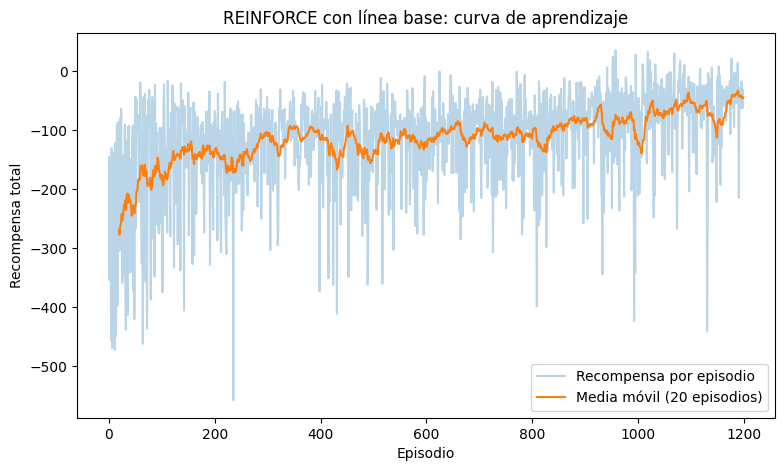

In [8]:
def moving_average(values, window):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


window = 20
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(episode_rewards, alpha=0.3, label="Recompensa por episodio")
smoothed = moving_average(episode_rewards, window)
ax.plot(range(window - 1, len(episode_rewards)), smoothed, label=f"Media móvil ({window} episodios)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total")
ax.set_title("REINFORCE con línea base: curva de aprendizaje")
ax.legend()
plt.show()

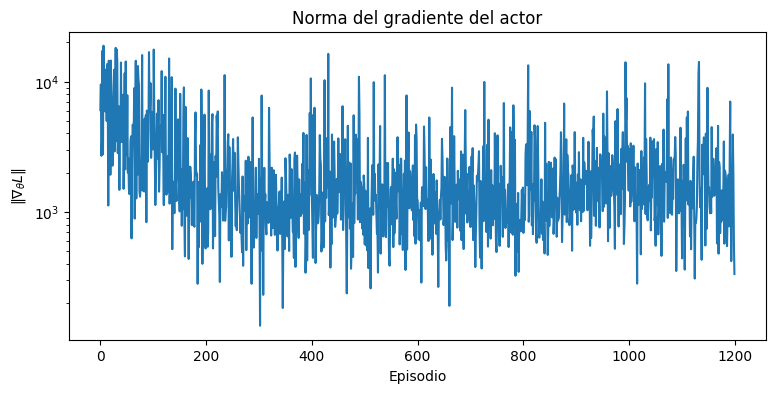

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grad_norms)
ax.set_yscale("log")
ax.set_xlabel("Episodio")
ax.set_ylabel(r"$\|\nabla_\theta L\|$")
ax.set_title("Norma del gradiente del actor")
plt.show()

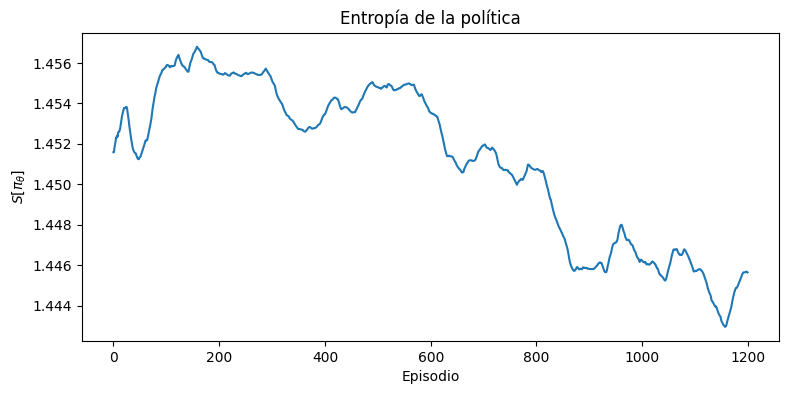

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(entropy_history)
ax.set_xlabel("Episodio")
ax.set_ylabel(r"$S[\pi_\theta]$")
ax.set_title("Entropía de la política")
plt.show()

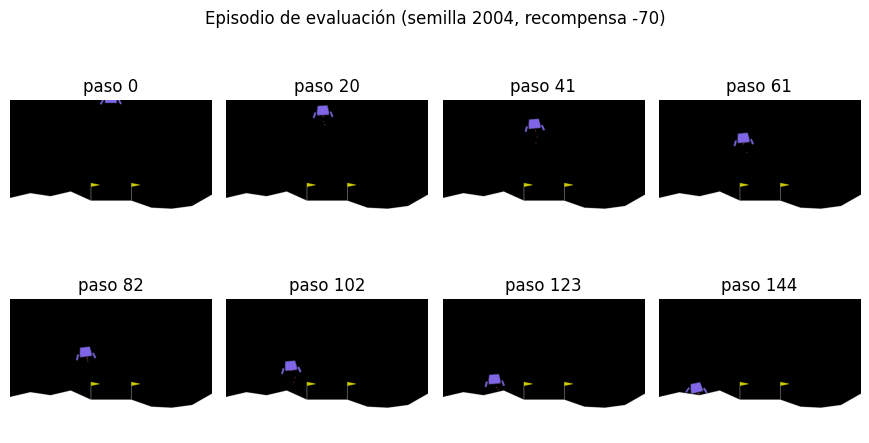

In [11]:
def evaluate_with_mean_action(env, policy_net, seed):
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    done = False
    while not done:
        state_t = torch.as_tensor(obs, dtype=torch.float32)
        with torch.no_grad():
            mean_action = policy_net(state_t).mean
        obs, reward, terminated, truncated, _ = env.step(np.clip(mean_action.numpy(), -1.0, 1.0))
        total_reward += reward
        done = terminated or truncated
    return total_reward


eval_env = gym.make(ENV_ID)
eval_rewards = {seed: evaluate_with_mean_action(eval_env, policy_net, seed) for seed in range(2000, 2015)}
eval_env.close()
best_seed = max(eval_rewards, key=eval_rewards.get)

render_env = gym.make(ENV_ID, render_mode="rgb_array")
obs, _ = render_env.reset(seed=best_seed)
frames = [render_env.render()]
done = False
while not done:
    state_t = torch.as_tensor(obs, dtype=torch.float32)
    with torch.no_grad():
        mean_action = policy_net(state_t).mean
    obs, _, terminated, truncated, _ = render_env.step(np.clip(mean_action.numpy(), -1.0, 1.0))
    frames.append(render_env.render())
    done = terminated or truncated
render_env.close()

num_frames = 8
indices = np.linspace(0, len(frames) - 1, num_frames).astype(int)
fig, axes = plt.subplots(2, num_frames // 2, figsize=(2.2 * (num_frames // 2), 5))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(frames[idx])
    ax.set_title(f"paso {idx}")
    ax.axis("off")
fig.suptitle(f"Episodio de evaluación (semilla {best_seed}, recompensa {eval_rewards[best_seed]:.0f})")
fig.tight_layout()
plt.show()

### Actor-Critic y comparación

Actor-Critic usa el error TD de un paso como estimación de la ventaja y actualiza en cada transición. El cuerpo de dos capas de 64 neuronas es compartido por el actor y el crítico; únicamente las cabezas de media y valor son independientes. Como hay varios gradientes del actor dentro de cada episodio, se registra su norma RMS para obtener una observación por episodio.

In [12]:
CRITIC_LR = 1e-3
VALUE_LOSS_COEF = 0.5


class ActorCriticNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
        )
        self.mean_head = nn.Sequential(nn.Linear(HIDDEN_SIZE, act_dim), nn.Tanh())
        self.log_std = nn.Parameter(torch.log(torch.full((act_dim,), 0.5)))
        self.value_head = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, state):
        features = self.body(state)
        mean = self.mean_head(features)
        std = self.log_std.exp().expand_as(mean)
        value = self.value_head(features).squeeze(-1)
        return Normal(mean, std), value

    def actor_parameters(self):
        return list(self.body.parameters()) + list(self.mean_head.parameters()) + [self.log_std]


def gradient_norm_from_tensors(gradients):
    squared_norm = sum(gradient.detach().pow(2).sum().item() for gradient in gradients if gradient is not None)
    return squared_norm ** 0.5


def train_actor_critic(num_episodes=NUM_EPISODES, seed=SEED):
    set_global_seed(seed)
    env = gym.make(ENV_ID)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    model = ActorCriticNetwork(obs_dim, act_dim)
    optimizer = torch.optim.Adam([
        {"params": model.body.parameters(), "lr": POLICY_LR},
        {"params": list(model.mean_head.parameters()) + [model.log_std], "lr": POLICY_LR},
        {"params": model.value_head.parameters(), "lr": CRITIC_LR},
    ])

    episode_rewards, grad_norms, entropy_history = [], [], []

    for episode in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0.0
        step_grad_norms, step_entropies = [], []

        while not done:
            state_t = torch.as_tensor(obs, dtype=torch.float32)
            dist, value = model(state_t)
            action_t = dist.sample()
            log_prob = dist.log_prob(action_t).sum()
            entropy = dist.entropy().sum()

            next_obs, reward, terminated, truncated, _ = env.step(
                np.clip(action_t.detach().numpy(), -1.0, 1.0)
            )
            next_state_t = torch.as_tensor(next_obs, dtype=torch.float32)
            with torch.no_grad():
                _, next_value = model(next_state_t)
                # Se anula el bootstrap solo en terminales reales, no por límite de tiempo.
                td_target = torch.as_tensor(reward, dtype=torch.float32)
                if not terminated:
                    td_target = td_target + GAMMA * next_value

            td_error = td_target - value
            actor_loss = -log_prob * td_error.detach()
            critic_loss = td_error.pow(2)

            actor_gradients = torch.autograd.grad(
                actor_loss, model.actor_parameters(), retain_graph=True, allow_unused=True
            )
            step_grad_norms.append(gradient_norm_from_tensors(actor_gradients))

            optimizer.zero_grad()
            (actor_loss + VALUE_LOSS_COEF * critic_loss).backward()
            optimizer.step()

            total_reward += reward
            step_entropies.append(entropy.detach().item())
            obs = next_obs
            done = terminated or truncated

        episode_rewards.append(total_reward)
        grad_norms.append(float(np.sqrt(np.mean(np.square(step_grad_norms)))))
        entropy_history.append(float(np.mean(step_entropies)))

        if (episode + 1) % 100 == 0:
            recent = np.mean(episode_rewards[-100:])
            print(f"Actor-Critic {episode + 1}/{num_episodes}  recompensa media (100) = {recent:.1f}")

    env.close()
    return model, episode_rewards, grad_norms, entropy_history


actor_critic_net, ac_episode_rewards, ac_grad_norms, ac_entropy_history = train_actor_critic()

Actor-Critic 100/1200  recompensa media (100) = -474.3
Actor-Critic 200/1200  recompensa media (100) = -350.9
Actor-Critic 300/1200  recompensa media (100) = -433.9
Actor-Critic 400/1200  recompensa media (100) = -455.0
Actor-Critic 500/1200  recompensa media (100) = -94.9
Actor-Critic 600/1200  recompensa media (100) = -105.6
Actor-Critic 700/1200  recompensa media (100) = -110.6
Actor-Critic 800/1200  recompensa media (100) = -144.7
Actor-Critic 900/1200  recompensa media (100) = -66.7
Actor-Critic 1000/1200  recompensa media (100) = -150.6
Actor-Critic 1100/1200  recompensa media (100) = 48.9
Actor-Critic 1200/1200  recompensa media (100) = 31.5


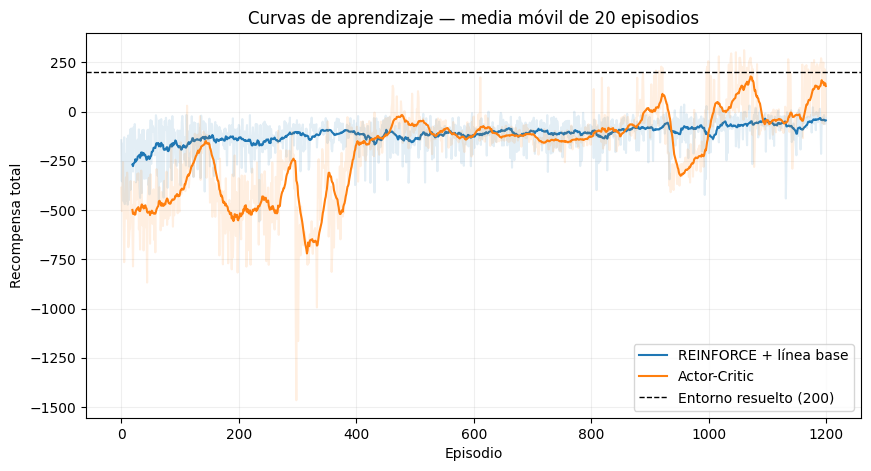

In [13]:
window = 20
fig, ax = plt.subplots(figsize=(10, 5))

for rewards, name, color in [
    (episode_rewards, "REINFORCE + línea base", "tab:blue"),
    (ac_episode_rewards, "Actor-Critic", "tab:orange"),
]:
    ax.plot(rewards, color=color, alpha=0.12)
    smoothed = moving_average(rewards, window)
    ax.plot(range(window - 1, len(rewards)), smoothed, color=color, label=name)

ax.axhline(200, color="black", linestyle="--", linewidth=1, label="Entorno resuelto (200)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total")
ax.set_title(f"Curvas de aprendizaje — media móvil de {window} episodios")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

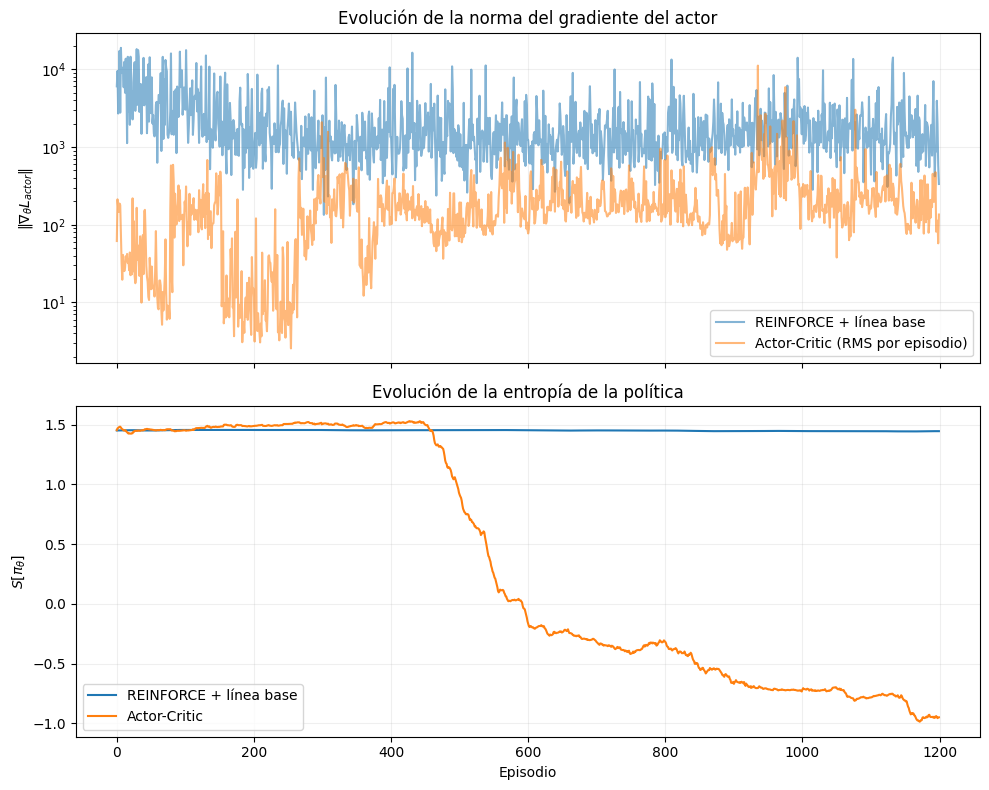

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(grad_norms, alpha=0.55, label="REINFORCE + línea base")
axes[0].plot(ac_grad_norms, alpha=0.55, label="Actor-Critic (RMS por episodio)")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$\|\nabla_\theta L_{actor}\|$")
axes[0].set_title("Evolución de la norma del gradiente del actor")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(entropy_history, label="REINFORCE + línea base")
axes[1].plot(ac_entropy_history, label="Actor-Critic")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel(r"$S[\pi_\theta]$")
axes[1].set_title("Evolución de la entropía de la política")
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

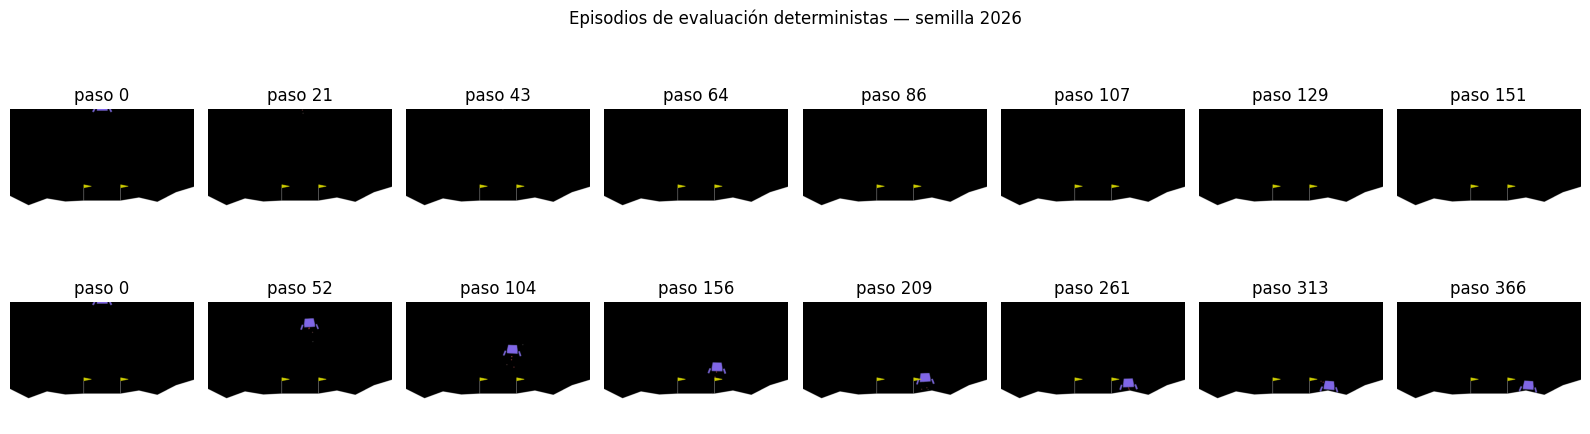

In [15]:
def policy_mean(model, state_t):
    output = model(state_t)
    distribution = output[0] if isinstance(output, tuple) else output
    return distribution.mean


def render_episode(model, seed):
    env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    done = False

    while not done:
        state_t = torch.as_tensor(obs, dtype=torch.float32)
        with torch.no_grad():
            action = policy_mean(model, state_t)
        obs, reward, terminated, truncated, _ = env.step(
            np.clip(action.numpy(), -1.0, 1.0)
        )
        total_reward += reward
        frames.append(env.render())
        done = terminated or truncated

    env.close()
    return frames, total_reward


evaluation_seed = 2026
rendered_episodes = [
    ("REINFORCE + línea base",) + render_episode(policy_net, evaluation_seed),
    ("Actor-Critic",) + render_episode(actor_critic_net, evaluation_seed),
]

num_frames = 8
fig, axes = plt.subplots(len(rendered_episodes), num_frames, figsize=(16, 5))
for row, (name, frames, reward) in enumerate(rendered_episodes):
    indices = np.linspace(0, len(frames) - 1, num_frames).astype(int)
    for column, frame_index in enumerate(indices):
        axes[row, column].imshow(frames[frame_index])
        axes[row, column].set_title(f"paso {frame_index}")
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(f"{name}\nR = {reward:.1f}")

fig.suptitle(f"Episodios de evaluación deterministas — semilla {evaluation_seed}")
fig.tight_layout()
plt.show()

Ambos algoritmo se ven potencialmente intestables, aunque REINFORCE mantiene normas de gradiente generalmente mayores y Actor Critic muestra picos aislados cercanos a 10 elevado a la cuarta potencia.

Estos resultados ilustran el problema que motivo PPO, una actualizacion con un gradiente demasiado grande, puede modificar demasiado la politica y destruir todo lo que aprendio. El clipping de PPO no elimina los gradientes altos directamenet , pero limita cuanto puede cambiar la probabilidad de las acciones entre actualizaciones , reduciendo el riesgo de colpsos bruscos

## Task 3

Con base en los resultados de la implementación y en investigación bibliográfica, realicen lo siguiente:

### Inciso 1

Contrasten cada predicción de la Tarea 1 con los resultados observados. Para cada predicción indiquen si fue confirmada, refutada o inconclusa. Una predicción refutada con buena explicación de la discrepancia vale más que una confirmada sin análisis.

**Respuesta:**

Los resultados corresponden a una ejecución con la misma semilla para ambos algoritmos. Por ello, permiten contrastar lo ocurrido en este experimento, pero no establecer una diferencia estadística general entre los métodos. Como evidencia se utilizan las salidas impresas cada 100 episodios y las tres figuras de la Tarea 2: **Curvas de aprendizaje — media móvil de 20 episodios**, **Evolución de la norma del gradiente del actor / entropía de la política** y **Episodios de evaluación deterministas**.

| Predicción de la Tarea 1 | Dictamen | Evidencia observada |
| :--- | :---: | :--- |
| Los métodos de gradiente de política pueden representar directamente acciones continuas, sin discretizar $[-1,1]^2$. | **Confirmada** | REINFORCE y Actor-Critic entrenaron una política Gaussiana bidimensional y produjeron acciones continuas para los dos propulsores. La figura **Episodios de evaluación deterministas** demuestra que ambas políticas pudieron ejecutarse con `env.render()`. Esto confirma la viabilidad de la representación elegida; no prueba experimentalmente que DQN sea imposible, porque DQN no fue implementado. |
| REINFORCE tendría alta varianza porque cada actualización utiliza el retorno Monte Carlo de todo el episodio. | **Confirmada** | En la figura de curvas de aprendizaje, la recompensa de REINFORCE presenta oscilaciones durante todo el entrenamiento. En la figura de gradientes, su norma se mantiene normalmente entre $10^3$ y $10^4$, con varios picos por encima de $10^4$. La línea base redujo parte de la varianza, pero no eliminó la aleatoriedad acumulada en $G_t$. |
| Al principio REINFORCE podría superar a Actor-Critic porque el crítico comienza con predicciones poco informativas. | **Confirmada** | En los primeros 100 episodios, REINFORCE obtuvo una recompensa media de $-206.9$, mientras Actor-Critic obtuvo $-474.3$. La curva naranja también muestra caídas cercanas a $-700$ durante los primeros 400 episodios. El crítico inicial introdujo errores TD poco fiables antes de aprender una aproximación útil de $V^\pi$. |
| Actor-Critic convergería más rápido que REINFORCE. | **Inconclusa** | Actor-Critic terminó con una media de $31.5$ en los últimos 100 episodios, mejor que el $-62.0$ de REINFORCE. Sin embargo, ninguno mantuvo el umbral de 200 puntos y Actor-Critic sufrió regresiones: pasó de $-66.7$ en el episodio 900 a $-150.6$ en el 1000, antes de recuperarse a $48.9$ en el 1100. Hay evidencia de mejor desempeño final, pero no de convergencia rápida y estable. |
| El error TD de un paso produciría en Actor-Critic una señal de menor varianza que el retorno completo de REINFORCE. | **Refutada en esta ejecución** | Aunque las normas RMS de Actor-Critic fueron generalmente menores, su curva de recompensa fue más irregular y tuvo colapsos más severos. La discrepancia puede explicarse porque una menor varianza del objetivo TD no garantiza una curva estable: el crítico aproximado introduce sesgo, el cuerpo compartido acopla las actualizaciones y la reducción rápida de $\sigma$ limita la exploración. Con una sola semilla, este dictamen no debe generalizarse a todos los entrenamientos. |
| Actor-Critic tendría mayor riesgo de colapso si las tasas de aprendizaje del actor y el crítico quedaban mal balanceadas. | **Confirmada** | La curva naranja alterna mejoras y pérdidas de desempeño, especialmente entre los episodios 800 y 1100. La figura de entropía aporta una segunda evidencia: la entropía de Actor-Critic cae con rapidez aproximadamente entre los episodios 450 y 600 y termina cerca de $-1$, mientras la de REINFORCE permanece alrededor de $1.44$. Actor-Critic se volvió casi determinista antes de estabilizar completamente su desempeño. |
| Actor-Critic sería más adecuado que REINFORCE para incorporar penalizaciones locales de suavidad en un exoesqueleto. | **Inconclusa** | LunarLander no incluyó la penalización $\lVert a_t-a_{t-1}\rVert^2$, el estado aumentado con $a_{t-1}$ ni límites explícitos sobre el cambio de torque. Por lo tanto, las gráficas no contienen evidencia directa sobre suavidad o seguridad física. Esta predicción tendría que evaluarse en otro experimento que registre el cambio entre acciones consecutivas. |

| Episodio | REINFORCE: media de los últimos 100 | Actor-Critic: media de los últimos 100 |
| ---: | ---: | ---: |
| 100 | $-206.9$ | $-474.3$ |
| 500 | $-131.3$ | $-94.9$ |
| 900 | $-97.5$ | $-66.7$ |
| 1000 | $-92.5$ | $-150.6$ |
| 1100 | $-64.9$ | $48.9$ |
| 1200 | $-62.0$ | $31.5$ |

En conjunto, la predicción principal solo fue respaldada parcialmente: Actor-Critic alcanzó un resultado final mejor, pero no convergió de forma monotónica ni resolvió el entorno. La evidencia visual y numérica muestra que su capacidad de aprender con señales TD vino acompañada de colapsos, picos de gradiente y una pérdida rápida de entropía. Esto apoya continuar desde Actor-Critic, pero también justifica introducir mecanismos de estabilización como regularización de entropía, normalización de ventajas y el *clipping* utilizado por PPO.

### Inciso 2

La norma $\lVert\nabla_\theta L\rVert$ durante el entrenamiento es un indicador de estabilidad. Describan su evolución para ambos algoritmos. ¿Hay episodios donde la norma es anormalmente alta? ¿Coinciden con caídas en la recompensa? ¿Qué implicación tiene eso sobre el problema de los pasos grandes que motivó PPO?

### Inciso 3

La entropía de la política debería decrecer gradualmente durante el entrenamiento a medida que la política se vuelve más determinista. ¿Observan ese comportamiento? ¿En qué punto del entrenamiento la entropía cae más rápido? ¿Qué consecuencia tendría agregar un término de entropía en la pérdida como hace PPO?

### Inciso 4

Busquen y lean un paper publicado entre 2022 y 2025 que aplique métodos de gradiente de política, Actor-Critic, PPO o una extensión directa de estos algoritmos al control de exoesqueletos, prótesis robóticas, rehabilitación médica, o asistencia de movilidad. El paper debe ser de IEEE Transactions on Neural Systems and Rehabilitation Engineering, Nature Machine Intelligence, NeurIPS, ICML, o similar. Escriban un resumen técnico de media página que incluya: el problema que resuelve, qué algoritmo de gradiente de política usa, por qué eligió ese algoritmo, los resultados principales, y una reflexión sobre qué limitaciones de REINFORCE y Actor-Critic que observaron en sus experimentos resuelve ese trabajo y cuáles persisten.

### Inciso 5

Redacten dos párrafos dirigidos al equipo directivo de la empresa de exoesqueletos. El primero debe argumentar si REINFORCE o Actor-Critic es más apropiado como punto de partida para el sistema real, con evidencia de sus experimentos. El segundo debe argumentar si recomiendan escalar directamente a PPO antes del despliegue en hardware, considerando las limitaciones de suavidad de acción identificadas en la Tarea 1 y los resultados de la investigación bibliográfica.

## Referencias

- [Policy gradient methods](http://www.scholarpedia.org/article/Policy_gradient_methods) — derivación formal del teorema.
- [Diving deeper into policy-gradient methods](https://huggingface.co/learn/deep-rl-course/unit4/policy-gradient)
- [Lunar Lander – Gymnasium](https://gymnasium.farama.org/environments/box2d/lunar_lander/) — especificación del entorno.